In [4]:
import argparse, os, re, sys
from pathlib import Path
import numpy as np, pandas as pd, h5py, matplotlib.pyplot as plt

# ---------- user-configurable -----------------------------------------
TIME_WINDOWS = [                    # (name, start_ms, end_ms)
    ('grey_pre',    0,   500),
    ('stimulus',  500,  2500),
    ('grey_post', 2500, 3000),
]
BIN_MS       = 20                   # for time-course plot
# ----------------------------------------------------------------------

# helper: classify interneuron vs pyramidal
def classify(pop_name: str) -> str:
    s = pop_name.lower()
    if 'pvalb' in s or re.search(r'\bpv', s): return 'PV'
    if 'sst'  in s:                           return 'SST'
    if 'vip' in s or 'htr3a' in s:            return 'VIP'
    return 'Pyr'

def load_spikes(fname: Path | str):
    """Return DataFrame (t_ms, gid)."""
    fname = Path(fname)
    if fname.suffix == '.h5':
        with h5py.File(fname, 'r') as f:
            # assume the single cortical group is /spikes/v1
            ts   = f['spikes']['v1']['timestamps'][...]
            gids = f['spikes']['v1']['node_ids'][...]
    else:  # plain text
        arr = np.loadtxt(fname)
        ts, gids = arr[:,0], arr[:,1].astype(int)
    return pd.DataFrame({'t_ms': ts, 'gid': gids})

def attach_population(df, node_file: Path | str):
    nodes = pd.read_csv(
        node_file, delim_whitespace=True,
        usecols=['id','pop_name','location']
    )
    nodes['type']       = nodes['pop_name'].apply(classify)
    nodes['population'] = nodes['location'] + '_' + nodes['type']
    gid_to_pop = dict(zip(nodes['id'], nodes['population']))
    df['population'] = df['gid'].map(gid_to_pop)
    cells_per_pop = nodes.groupby('population').size()
    return cells_per_pop

In [5]:
dirpath_root = Path(r'D:\WORK\Salvador\doc\Tuning\Allen_model')
os.chdir(dirpath_root)

fpath_nodes = 'v1_nodes.csv'
fpath_spikes = 'spikes_driftingGratings_ori0.0_trial0'

spikes = load_spikes(fpath_spikes)
run_dur_s = spikes['t_ms'].max() / 1000.0
n_cells_total = len(np.unique(spikes['gid']))

In [ ]:
# Pop. rates
cells_per_pop = attach_population(spikes, fpath_nodes)
counts_tot = spikes.groupby('population').size()
rates = pd.DataFrame({
    'n_cells'   : cells_per_pop,
    'overall_Hz': counts_tot / cells_per_pop / run_dur_s
})
for name, t0, t1 in TIME_WINDOWS:
    mask = (spikes['t_ms']>=t0) & (spikes['t_ms']<t1)
    cnt  = spikes.loc[mask].groupby('population').size()
    rates[f'{name}_Hz'] = cnt / cells_per_pop / ((t1-t0)/1e3)
rates = rates.fillna(0).sort_index()
print('\nPer-population rates (Hz):')
print(rates.round(3).to_string())

C:\Users\aleks\AppData\Local\Temp\ipykernel_150524\3894359877.py:36: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  nodes = pd.read_csv(



Per-population rates (Hz):
            n_cells  overall_Hz  grey_pre_Hz  stimulus_Hz  grey_post_Hz
population                                                             
VisL1_VIP      4363       1.031        0.467        1.144         1.146
VisL23_PV      2927       2.858        0.264        3.234         3.947
VisL23_Pyr    56057       0.579        0.037        0.673         0.746
VisL23_SST     2120       0.686        0.230        0.751         0.881
VisL23_VIP     4845       0.782        0.419        0.844         0.894
VisL4_PV       4461       9.813        2.439       11.144        11.866
VisL4_Pyr     45761       0.737        0.075        0.856         0.920
VisL4_SST      2384       1.902        0.372        2.196         2.259
VisL4_VIP      1231       1.483        0.305        1.719         1.719
VisL5_PV       2876       9.371        1.792       10.734        11.497
VisL5_Pyr     33558       2.473        0.443        2.844         3.019
VisL5_SST      2538       0.565     

In [17]:
#cells_per_pop
tc = (spikes.groupby(['population','bin']).size()
                .unstack(fill_value=0) / BIN_MS * 1000)  # Hz
tc = tc.sort_index()
tc

bin,0,1,2,3,4,5,6,7,8,9,...,140,141,142,143,144,145,146,147,148,149
population,,,,,,,,,,,,,,,,,,,,,
VisL1_VIP,2350.0,2350.0,2200.0,400.0,2050.0,2250.0,2650.0,1150.0,1200.0,2700.0,...,2700.0,4050.0,5200.0,3850.0,3450.0,5450.0,6750.0,5900.0,4700.0,4650.0
VisL23_PV,300.0,1150.0,1150.0,200.0,800.0,700.0,600.0,500.0,450.0,950.0,...,8200.0,6150.0,9800.0,16050.0,5150.0,6600.0,11550.0,9450.0,17700.0,11900.0
VisL23_Pyr,0.0,1000.0,1900.0,800.0,750.0,2150.0,2900.0,600.0,1900.0,1300.0,...,28150.0,30500.0,35850.0,52100.0,25050.0,34200.0,47450.0,39700.0,57650.0,38650.0
VisL23_SST,0.0,0.0,0.0,0.0,0.0,0.0,2550.0,450.0,0.0,0.0,...,1150.0,0.0,200.0,3200.0,250.0,1250.0,2900.0,2200.0,4900.0,1250.0
VisL23_VIP,350.0,0.0,100.0,50.0,50.0,200.0,7950.0,1050.0,400.0,800.0,...,3100.0,600.0,1050.0,7500.0,900.0,3200.0,5250.0,5150.0,11150.0,3850.0
VisL4_PV,3850.0,12050.0,11750.0,6800.0,13200.0,10900.0,10300.0,6650.0,10400.0,13900.0,...,38750.0,44400.0,51600.0,55800.0,42500.0,49350.0,53900.0,47950.0,66000.0,52850.0
VisL4_Pyr,200.0,4550.0,3700.0,1950.0,2700.0,4000.0,4000.0,1150.0,4600.0,2800.0,...,29800.0,33000.0,39300.0,50600.0,30000.0,35500.0,43650.0,38150.0,57200.0,42850.0
VisL4_SST,0.0,0.0,100.0,0.0,0.0,50.0,6350.0,50.0,0.0,50.0,...,3000.0,350.0,1050.0,8600.0,1350.0,5000.0,6400.0,3900.0,11600.0,6350.0
VisL4_VIP,0.0,100.0,500.0,0.0,0.0,300.0,1000.0,200.0,0.0,0.0,...,1900.0,250.0,400.0,4250.0,450.0,2450.0,3100.0,950.0,4300.0,2000.0


In [22]:
tc_normalized = tc.div(cells_per_pop, axis=0)
tc_normalized

bin,0,1,2,3,4,5,6,7,8,9,...,140,141,142,143,144,145,146,147,148,149
population,,,,,,,,,,,,,,,,,,,,,
VisL1_VIP,0.538620,0.538620,0.504240,0.091680,0.469860,0.515700,0.607380,0.263580,0.275040,0.618840,...,0.618840,0.928260,1.191840,0.882420,0.790740,1.249140,1.547101,1.352281,1.077240,1.065780
VisL23_PV,0.102494,0.392894,0.392894,0.068329,0.273317,0.239153,0.204988,0.170823,0.153741,0.324564,...,2.801503,2.101127,3.348138,5.483430,1.759481,2.254868,3.946020,3.228562,6.047147,4.065596
VisL23_Pyr,0.000000,0.017839,0.033894,0.014271,0.013379,0.038354,0.051733,0.010703,0.033894,0.023191,...,0.502167,0.544089,0.639528,0.929411,0.446867,0.610093,0.846460,0.708208,1.028418,0.689477
VisL23_SST,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.202830,0.212264,0.000000,0.000000,...,0.542453,0.000000,0.094340,1.509434,0.117925,0.589623,1.367925,1.037736,2.311321,0.589623
VisL23_VIP,0.072239,0.000000,0.020640,0.010320,0.010320,0.041280,1.640867,0.216718,0.082559,0.165119,...,0.639835,0.123839,0.216718,1.547988,0.185759,0.660475,1.083591,1.062951,2.301342,0.794634
VisL4_PV,0.863035,2.701188,2.633939,1.524322,2.958978,2.443398,2.308899,1.490697,2.331316,3.115893,...,8.686393,9.952925,11.566913,12.508406,9.527012,11.062542,12.082493,10.748711,14.794889,11.847119
VisL4_Pyr,0.004371,0.099430,0.080855,0.042613,0.059002,0.087411,0.087411,0.025131,0.100522,0.061187,...,0.651210,0.721138,0.858810,1.105745,0.655580,0.775770,0.953869,0.833679,1.249973,0.936387
VisL4_SST,0.000000,0.000000,0.041946,0.000000,0.000000,0.020973,2.663591,0.020973,0.000000,0.020973,...,1.258389,0.146812,0.440436,3.607383,0.566275,2.097315,2.684564,1.635906,4.865772,2.663591
VisL4_VIP,0.000000,0.081235,0.406174,0.000000,0.000000,0.243704,0.812348,0.162470,0.000000,0.000000,...,1.543461,0.203087,0.324939,3.452478,0.365556,1.990252,2.518278,0.771730,3.493095,1.624695


In [ ]:
# Timecourse
bin_edges = np.arange(0, spikes['t_ms'].max()+BIN_MS, BIN_MS)
spikes['bin'] = np.searchsorted(bin_edges, spikes['t_ms'], 'right')-1
tc = (spikes.groupby(['population','bin']).size()
                .unstack(fill_value=0) / BIN_MS * 1000)  # Hz
tc = tc.sort_index()
tc = tc.div(cells_per_pop, axis=0)

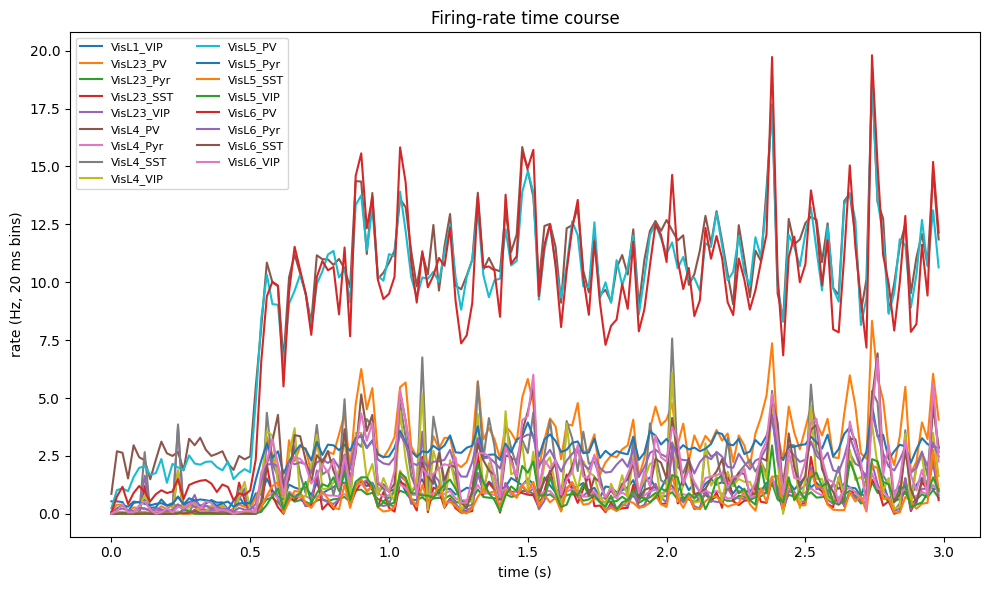

In [26]:
plt.figure(figsize=(10,6))
for pop in tc.index:
    plt.plot(bin_edges[:-1]/1000.0, tc.loc[pop], label=pop)
plt.legend(fontsize=8, ncol=2)
plt.xlabel('time (s)')
plt.ylabel(f'rate (Hz, {BIN_MS} ms bins)')
plt.title('Firing-rate time course')
plt.tight_layout()
#plt.xlim(0, 0.5)
plt.show()

1.575757575757576